<a href="https://colab.research.google.com/github/NakshatraDigala/Codegnan_Python/blob/main/ML_Parkinsons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORTING LIBRARIES**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

**LOAD DATASET**

In [ ]:
df = pd.read_csv('/content/parkinsons_disease_data.csv')

df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


**DATASET INFORMATION**

In [ ]:
print("Shape:", df.shape)    #shape->(rows,columns)
df.info()    #info(): column name,data type, missing values

Shape: (2105, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 2105 non-null   int64  
 1   Age                       2105 non-null   int64  
 2   Gender                    2105 non-null   int64  
 3   Ethnicity                 2105 non-null   int64  
 4   EducationLevel            2105 non-null   int64  
 5   BMI                       2105 non-null   float64
 6   Smoking                   2105 non-null   int64  
 7   AlcoholConsumption        2105 non-null   float64
 8   PhysicalActivity          2105 non-null   float64
 9   DietQuality               2105 non-null   float64
 10  SleepQuality              2105 non-null   float64
 11  FamilyHistoryParkinsons   2105 non-null   int64  
 12  TraumaticBrainInjury      2105 non-null   int64  
 13  Hypertension              2105 non-null   int

**STATISTICAL SUMMARY**

In [ ]:
df.describe()  #describe() gives:
#Count,Mean,Standard Deviation,Minimum,Maximum,Quartiles

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis
count,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,...,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,4110.000000,69.601900,0.492637,0.692637,1.337292,27.209493,0.296437,10.040413,5.016674,4.912901,...,15.094314,4.989694,0.431829,0.252732,0.207601,0.138717,0.295012,0.245131,0.296912,0.619477
std,607.805479,11.594511,0.500065,1.003827,0.895840,7.208099,0.456795,5.687014,2.890919,2.872115,...,8.643014,2.933877,0.495449,0.434682,0.405686,0.345733,0.456156,0.430267,0.457006,0.485631
min,3058.000000,50.000000,0.000000,0.000000,0.000000,15.008333,0.000000,0.002228,0.004157,0.000011,...,0.021191,0.001505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3584.000000,60.000000,0.000000,0.000000,1.000000,20.782176,0.000000,5.150278,2.455703,2.478503,...,7.517160,2.415890,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4110.000000,70.000000,0.000000,0.000000,1.000000,27.184571,0.000000,10.070337,5.031550,4.825187,...,14.963574,4.983227,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,4636.000000,80.000000,1.000000,1.000000,2.000000,33.462452,1.000000,14.829565,7.512795,7.381487,...,22.608362,7.484220,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,5162.000000,89.000000,1.000000,3.000000,3.000000,39.999887,1.000000,19.988866,9.995255,9.995864,...,29.970107,9.992697,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**MISSING VALUES CHECK**

In [ ]:
df.isnull().sum()  #returns null values sum

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


**DUPLICATE RECORDS CHECK**

In [ ]:
df.duplicated().sum()  #checks duplicated rows and returns count

np.int64(0)

**REMOVE UNNECESSARY COLUMNS**

In [ ]:
df.drop(['PatientID','DoctorInCharge'],axis=1,inplace=True)    #axis=1 says to look for those names in columns
df.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis
0,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,9.283194,...,29.181289,1.572427,1,0,0,0,0,0,0,0
1,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,5.602470,...,12.332639,4.787551,0,1,0,1,0,1,0,1
2,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,9.929824,...,29.927783,2.130686,1,0,0,0,1,0,1,1
3,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,4.196189,...,21.304268,3.391288,1,1,1,0,0,0,1,1
4,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,9.363925,...,8.336364,3.200969,0,0,0,1,0,1,0,0


**TARGET DISTRIBUTION BAR PLOT**

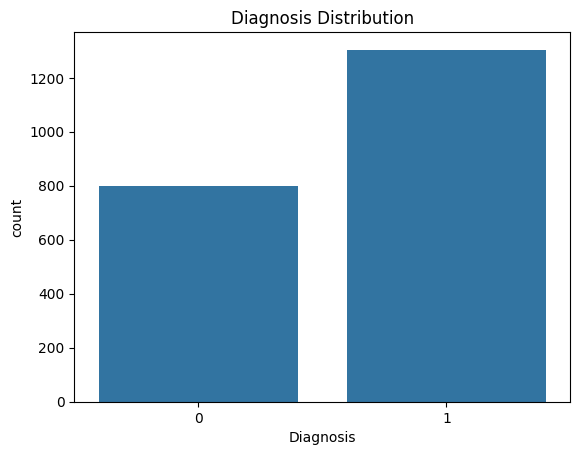

In [ ]:
sns.countplot(x='Diagnosis',data=df)  # tells the Seaborn Library to look at the 'Diagnosis' column in your dataset (df),
#count how many times each diagnosis appears, and draw a bar for each.
#sns--seaborn
#countplot--how many 0:Healthy, 1:Parkinson's
plt.title('Diagnosis Distribution')
plt.show()

**CORRELATION HEATMAP**

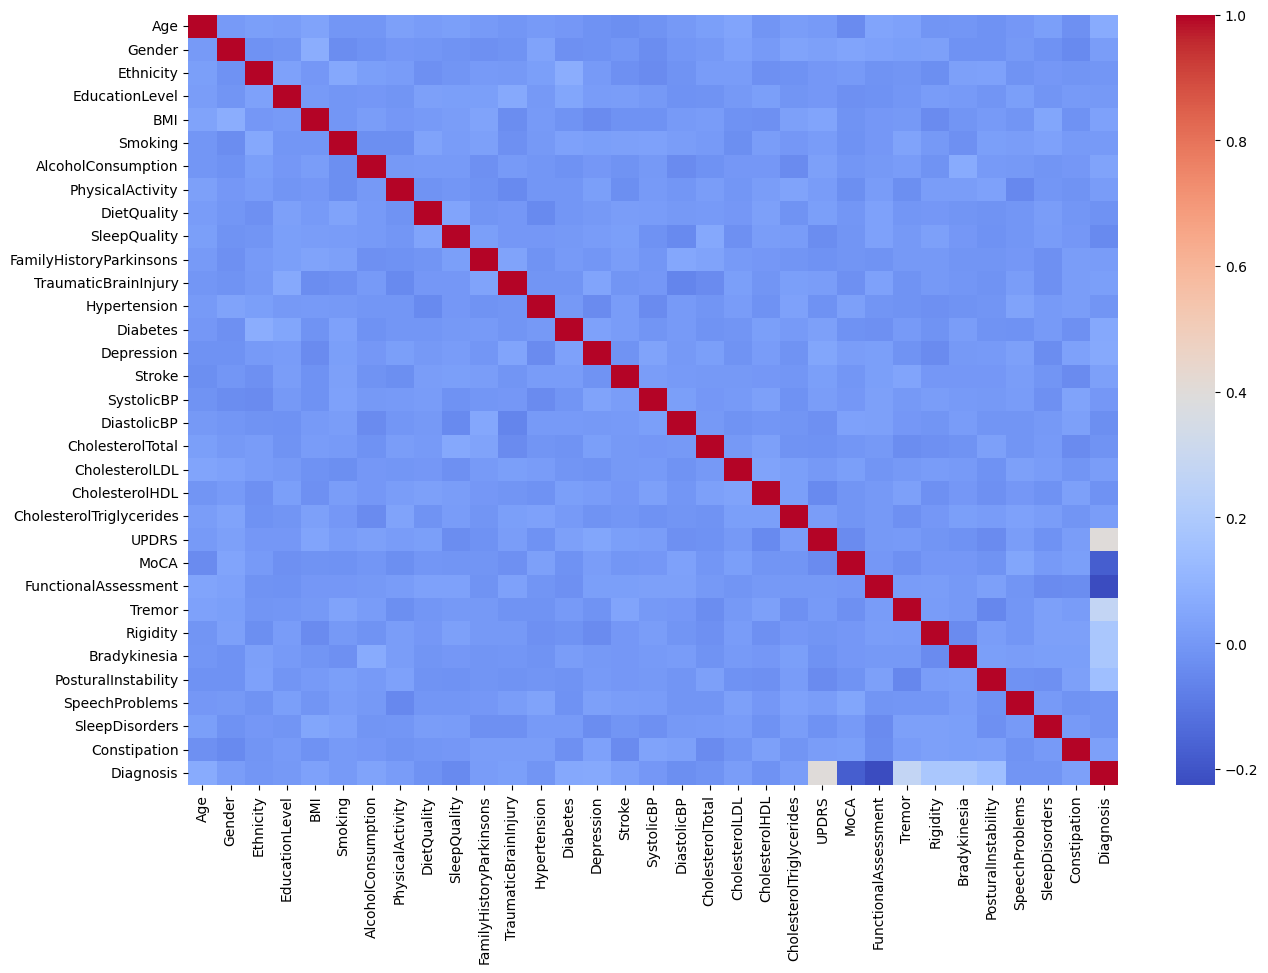

In [ ]:
plt.figure(figsize=(15,10))  #Sets the canvas size.15->width and 10->height
sns.heatmap(
    df.corr(),  #df.corr(): Calculates the correlation coefficients between all pairs of numeric columns.
    cmap='coolwarm')  #cmap='coolwarm': Uses a blue-to-red color scheme. blue->strong -ve
#correaltion ranges:
# +1-> strong positive
# 0-> no relation
# -1-> strong negative
plt.show()

**SEPARATING FEATURE AND TARGET**

In [ ]:
X=df.drop('Diagnosis',axis=1) #dataset X without diagnosis column
y=df['Diagnosis']    #contains only diagnosis column
print(X.shape)     #prints (rows,columns) of feature set
print(y.shape)   #prints(rows,)-->no of elements

(2105, 32)
(2105,)


**TRAIN-TEST SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split  #imports utility funtion needed to divide the data

#X_train: Features used to train the model (80% of the data).
#X_test: Features held back to test the model's accuracy (20% of the data).
#y_train: Correct answers/labels matching the training features.
#y_test: Correct answers/labels matching the testing features.
X_train, X_test, y_train, y_test = train_test_split(
    X,#features dataset
    y,#target dataset
    test_size=0.2,# 20% of the rows to the test set
    random_state=42
)

print(X_train.shape)#prints split data shape(training data)
print(X_test.shape)#prints test data shape

(1684, 32)
(421, 32)


**FEATURE SCALING**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**---LOGISTIC REGRESSION---**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)   #Train the model

y_pred_lr = lr.predict(X_test_scaled)    #Generate predictions

**EVALUATE LOGISTIC REGRESSION**

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

Accuracy: 0.7767220902612827
Precision: 0.8149466192170819
Recall: 0.8450184501845018
F1 Score: 0.8297101449275363


**---KNN---**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

**EVALUATE KNN**

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_knn))

print("Precision:",
      precision_score(y_test, y_pred_knn))

print("Recall:",
      recall_score(y_test, y_pred_knn))

print("F1 Score:",
      f1_score(y_test, y_pred_knn))

Accuracy: 0.7315914489311164
Precision: 0.7862318840579711
Recall: 0.8007380073800738
F1 Score: 0.793418647166362


**---SVM---**

In [ ]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

**EVALUATE SVM**

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("Precision:",
      precision_score(y_test, y_pred_svm))

print("Recall:",
      recall_score(y_test, y_pred_svm))

print("F1 Score:",
      f1_score(y_test, y_pred_svm))

Accuracy: 0.7838479809976246
Precision: 0.8169014084507042
Recall: 0.8560885608856088
F1 Score: 0.836036036036036


**RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)  #Random Forest does NOT require scaling That's why we use: X_train, X_test instead of: X_train_scaled, X_test_scaled

y_pred_rf = rf.predict(X_test)

**EVALUATE RANDOM FOREST--**

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

Accuracy: 0.8954869358669834
Precision: 0.9348659003831418
Recall: 0.9003690036900369
F1 Score: 0.9172932330827067


**---MLP(Neural Network)---**

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

**EVALUATE MLP**

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_mlp))

print("Precision:",
      precision_score(y_test, y_pred_mlp))

print("Recall:",
      recall_score(y_test, y_pred_mlp))

print("F1 Score:",
      f1_score(y_test, y_pred_mlp))

Accuracy: 0.8123515439429929
Precision: 0.875
Recall: 0.8265682656826568
F1 Score: 0.8500948766603416


**CONFUSION MATRIX**

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[133  17]
 [ 27 244]]


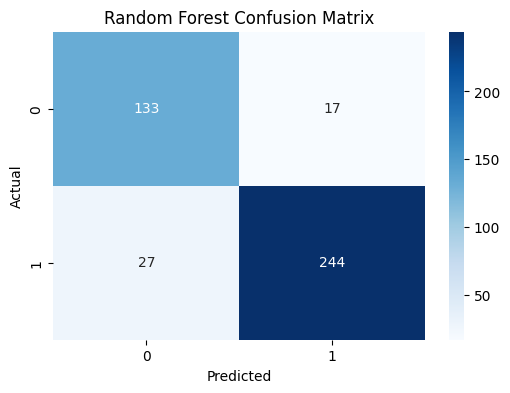

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

**Save the Best Model**

In [ ]:
import joblib

joblib.dump(rf, "parkinsons_model.pkl")  #joblib.dump() stores the trained model on disk. The model can later be loaded without retraining.

print("Model Saved Successfully")

Model Saved Successfully


**PHASE-2 AGENT**

**SAYS YES OR NO**

In [ ]:
def predict_parkinsons(patient_data):

    prediction = rf.predict([patient_data])

    if prediction[0] == 1:
        return "Parkinson's Detected"

    return "Healthy"

**SAMPLE INPUT**

In [ ]:
sample_patient = X_test.iloc[1].tolist()  #Select rows and columns by their position (index)

result = predict_parkinsons(sample_patient)

print(result)

Healthy


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


**SMALL HEALTHCARE ASSISTANT**

**It performs multiple related tasks**

In [ ]:
def health_agent(patient_data):

    prediction = rf.predict([patient_data])[0]

    probability = rf.predict_proba([patient_data])[0]

    if prediction == 1:

        print("Prediction : Parkinson's Detected")

        print(
            "Confidence :",
            round(max(probability)*100,2),
            "%"
        )

        print(
            "Recommendation : Consult a neurologist."
        )

    else:

        print("Prediction : Healthy")

        print(
            "Confidence :",
            round(max(probability)*100,2),
            "%"
        )

        print(
            "Recommendation : Maintain healthy lifestyle."
        )

In [ ]:
sample_patient = X_test.iloc[0].tolist()

health_agent(sample_patient)

Prediction : Healthy
Confidence : 69.0 %
Recommendation : Maintain healthy lifestyle.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
joblib.dump(rf, "parkinsons_model.pkl")
joblib.dump(scaler, "scaler.pkl")   # Only if we use a scaled model

['scaler.pkl']